# ДЗ №12. Python для аналитиков ИБ: форензика

## Этап 1. Загрузка данных

In [ ]:
pip install pandas matplotlib seaborn

In [ ]:
pip install pyshark

In [3]:
import os
import io
import subprocess
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyshark

In [4]:
TSHARK_PATH = r"C:\Program Files\Wireshark\tshark.exe"
PCAP_PATH = r".\dhcp.pcapng"
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

In [5]:
assert os.path.exists(TSHARK_PATH), f"tshark not found: {TSHARK_PATH}"
assert os.path.exists(PCAP_PATH), f"pcap not found: {PCAP_PATH}"

print(subprocess.check_output([TSHARK_PATH, "-v"], text=True).splitlines()[0])

TShark (Wireshark) 4.6.3 (v4.6.3-0-g648f69f3e168).


In [6]:
def run_tshark(args: list[str]) -> str:
    cmd = [TSHARK_PATH] + args
    p = subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", errors="replace")

    if p.returncode != 0:
        raise RuntimeError("tshark failed:\n" + p.stderr)
    
    return p.stdout

In [7]:
def tshark_fields_to_df(pcap_path: str, display_filter: str, fields: list[str]) -> pd.DataFrame:
    cmd = [
        "-r", pcap_path,
        "-Y", display_filter,
        "-T", "fields",
        "-E", "header=y",
        "-E", "separator=,",
        "-E", "quote=d",
        "-E", "occurrence=f",
    ]

    for f in fields:
        cmd += ["-e", f]

    out = run_tshark(cmd).strip()

    if not out:
        return pd.DataFrame(columns=fields)

    return pd.read_csv(io.StringIO(out))

## Этап 2. Извлечение ключевых артефактов

### DNS

В дампе ожидается, что DNS может отсутствовать, поэтому сначала проверяем наличие DNS-запросов.

In [8]:
def extract_dns(pcap_path: str) -> pd.DataFrame:
    df = tshark_fields_to_df(
        pcap_path=pcap_path,
        display_filter="dns && dns.flags.response == 0",
        fields=["frame.time_epoch", "ip.src", "ip.dst", "dns.qry.name", "dns.qry.type"],
    )

    if df.empty:
        print("[OK] DNS-запросы не обнаружены (0 записей).")

        return pd.DataFrame(columns=["time", "src_ip", "dst_ip", "query_name", "query_type"])

    df["time"] = pd.to_datetime(df["frame.time_epoch"], unit="s", errors="coerce")
    
    df = df.rename(columns={
        "ip.src": "src_ip",
        "ip.dst": "dst_ip",
        "dns.qry.name": "query_name",
        "dns.qry.type": "query_type",
    }).drop(columns=["frame.time_epoch"])

    return df

In [9]:
df_dns = extract_dns(PCAP_PATH)
df_dns.head(), len(df_dns)

[OK] DNS-запросы не обнаружены (0 записей).


(Empty DataFrame
 Columns: [time, src_ip, dst_ip, query_name, query_type]
 Index: [],
 0)

### DHCP

In [10]:
def extract_dhcp(pcap_path: str) -> pd.DataFrame:
    df = tshark_fields_to_df(
        pcap_path=pcap_path,
        display_filter="bootp",
        fields=[
            "frame.time_epoch",
            "ip.src",
            "ip.dst",
            "bootp.option.dhcp",
            "bootp.option.hostname",
            "bootp.option.requested_ip_address",
            "bootp.hw.mac_addr",
        ],
    )

    if df.empty:
        print("[!] DHCP/BOOTP пакеты не обнаружены.")

        return pd.DataFrame(columns=["time", "src_ip", "dst_ip", "dhcp_type", "hostname", "requested_ip", "assigned_ip", "client_mac"])

    df["time"] = pd.to_datetime(df["frame.time_epoch"], unit="s", errors="coerce")
    
    df = df.rename(columns={
        "ip.src": "src_ip",
        "ip.dst": "dst_ip",
        "bootp.option.dhcp": "dhcp_type",
        "bootp.option.hostname": "hostname",
        "bootp.option.requested_ip_address": "requested_ip",
        "bootp.hw.mac_addr": "client_mac",
    }).drop(columns=["frame.time_epoch"])

    return df

In [11]:
df_dhcp = extract_dhcp(PCAP_PATH)
df_dhcp.head(), len(df_dhcp)

(        src_ip           dst_ip  dhcp.option.dhcp  dhcp.option.hostname  \
 0      0.0.0.0  255.255.255.255                 1                   NaN   
 1  192.168.0.1     192.168.0.10                 2                   NaN   
 2      0.0.0.0  255.255.255.255                 3                   NaN   
 3  192.168.0.1     192.168.0.10                 5                   NaN   
 
   dhcp.option.requested_ip_address   dhcp.hw.mac_addr  \
 0                          0.0.0.0  00:0b:82:01:fc:42   
 1                              NaN  00:0b:82:01:fc:42   
 2                     192.168.0.10  00:0b:82:01:fc:42   
 3                              NaN  00:0b:82:01:fc:42   
 
                            time  
 0 2004-12-05 19:16:24.317452908  
 1 2004-12-05 19:16:24.317748070  
 2 2004-12-05 19:16:24.387484074  
 3 2004-12-05 19:16:24.387798071  ,
 4)

In [12]:
df_dhcp = df_dhcp.rename(columns={
    "dhcp.option.dhcp": "dhcp_type",
    "dhcp.option.hostname": "hostname",
    "dhcp.option.requested_ip_address": "requested_ip",
    "dhcp.hw.mac_addr": "client_mac",
})

DHCP_TYPE_MAP = {
    1: "DISCOVER",
    2: "OFFER",
    3: "REQUEST",
    5: "ACK",
    6: "NAK",
    7: "RELEASE",
    8: "INFORM",
}

df_dhcp["dhcp_type_num"] = pd.to_numeric(df_dhcp["dhcp_type"], errors="coerce")
df_dhcp["dhcp_type_name"] = df_dhcp["dhcp_type_num"].map(DHCP_TYPE_MAP).fillna(df_dhcp["dhcp_type"].astype(str))

df_dhcp[["time", "src_ip", "dst_ip", "dhcp_type", "dhcp_type_name", "hostname", "requested_ip", "client_mac"]]

,time,src_ip,dst_ip,dhcp_type,dhcp_type_name,hostname,requested_ip,client_mac
0,2004-12-05 19:16:24.317452908,0.0.0.0,255.255.255.255,1,DISCOVER,NaN,0.0.0.0,00:0b:82:01:fc:42
1,2004-12-05 19:16:24.317748070,192.168.0.1,192.168.0.10,2,OFFER,NaN,NaN,00:0b:82:01:fc:42
2,2004-12-05 19:16:24.387484074,0.0.0.0,255.255.255.255,3,REQUEST,NaN,192.168.0.10,00:0b:82:01:fc:42
3,2004-12-05 19:16:24.387798071,192.168.0.1,192.168.0.10,5,ACK,NaN,NaN,00:0b:82:01:fc:42


### TCP/UDP

In [13]:
def extract_connections(pcap_path: str) -> pd.DataFrame:
    df = tshark_fields_to_df(
        pcap_path=pcap_path,
        display_filter="tcp || udp",
        fields=[
            "frame.time_epoch",
            "ip.src",
            "ip.dst",
            "tcp.srcport",
            "tcp.dstport",
            "udp.srcport",
            "udp.dstport",
            "_ws.col.Protocol",
        ],
    )

    if df.empty:
        print("[!] TCP/UDP пакеты не обнаружены.")
        
        return pd.DataFrame(columns=["time", "protocol", "src_ip", "src_port", "dst_ip", "dst_port"])

    df["time"] = pd.to_datetime(df["frame.time_epoch"], unit="s", errors="coerce")
    df["src_port"] = df["tcp.srcport"].fillna(df["udp.srcport"])
    df["dst_port"] = df["tcp.dstport"].fillna(df["udp.dstport"])

    df = df.rename(columns={
        "ip.src": "src_ip",
        "ip.dst": "dst_ip",
        "_ws.col.Protocol": "protocol",
    }).drop(columns=["frame.time_epoch", "tcp.srcport", "tcp.dstport", "udp.srcport", "udp.dstport"])

    return df

In [14]:
df_conn = extract_connections(PCAP_PATH)
df_conn.head(), len(df_conn)

(        src_ip           dst_ip _ws.col.protocol  \
 0      0.0.0.0  255.255.255.255             DHCP   
 1  192.168.0.1     192.168.0.10             DHCP   
 2      0.0.0.0  255.255.255.255             DHCP   
 3  192.168.0.1     192.168.0.10             DHCP   
 
                            time  src_port  dst_port  
 0 2004-12-05 19:16:24.317452908      68.0      67.0  
 1 2004-12-05 19:16:24.317748070      67.0      68.0  
 2 2004-12-05 19:16:24.387484074      68.0      67.0  
 3 2004-12-05 19:16:24.387798071      67.0      68.0  ,
 4)

## Этап 3. Визуализация результатов

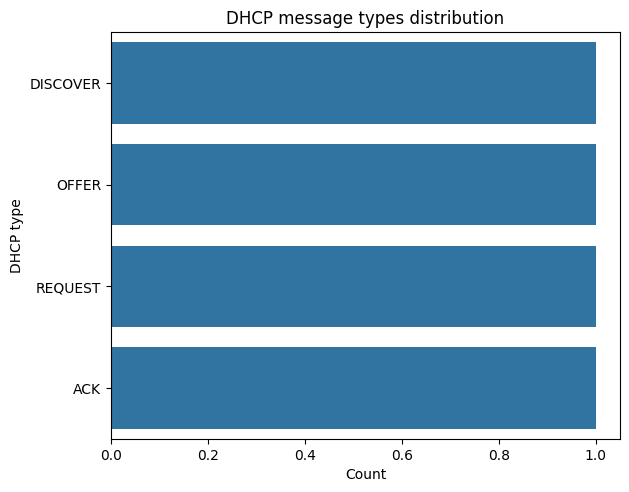

In [21]:
top_types = df_dhcp["dhcp_type_name"].fillna("UNKNOWN").value_counts().reset_index()
top_types.columns = ["dhcp_type", "count"]

plt.figure()
sns.barplot(data=top_types, x="count", y="dhcp_type")
plt.tight_layout()
plt.title("DHCP message types distribution")
plt.xlabel("Count")
plt.ylabel("DHCP type")
plt.show()

In [16]:
top_src = df_conn["src_ip"].value_counts().head(10).reset_index()
top_src.columns = ["src_ip", "count"]

top_dst = df_conn["dst_ip"].value_counts().head(10).reset_index()
top_dst.columns = ["dst_ip", "count"]

top_src, top_dst

(        src_ip  count
 0      0.0.0.0      2
 1  192.168.0.1      2,
             dst_ip  count
 0  255.255.255.255      2
 1     192.168.0.10      2)

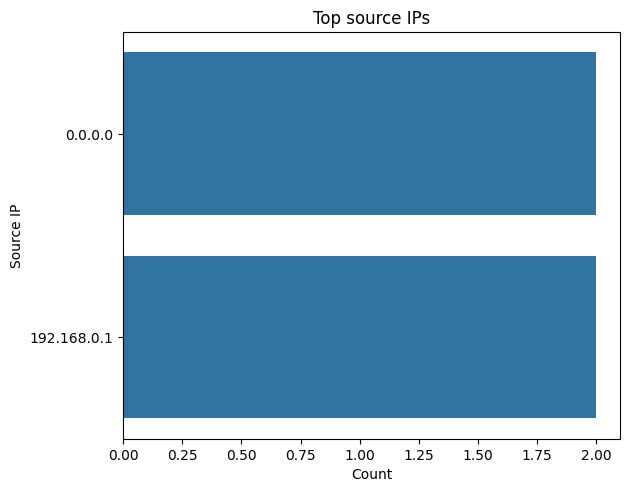

In [17]:
plt.figure()
sns.barplot(data=top_src, x="count", y="src_ip")
plt.tight_layout()
plt.title("Top source IPs")
plt.xlabel("Count")
plt.ylabel("Source IP")
plt.show()

In [20]:
df_dns.to_csv(OUT_DIR / "dns_requests.csv", index=False)
df_dhcp.to_csv(OUT_DIR / "dhcp_events.csv", index=False)
df_conn.to_csv(OUT_DIR / "connections.csv", index=False)

## Чек-лист самопроверки
- Установлены необходимые библиотеки и инструменты: pyshark ✓
- Дамп памяти или дамп сети успешно загружен ✓
- С помощью pyshark получены ключевые артефакты: имена процессов, IP-адреса, DNS-запросы ✓
- Создана минимальная визуализация или лог с результатами анализа ✓
- Результат выполнения лабораторной работы соответствует требованиям задания ✓
- На учебной платформе прикреплена ссылка на GitHub-репозиторий с кодом ✓
- Репозиторий по ссылке доступен для просмотра другим пользователям, название репозитория содержит фамилию и имя студента, номер лабораторной работы ✓